# PCA through Singular Value Decomposition

In [25]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]]) # -> 3 points f(2) = 4, f(1) = 3, f(0) = 0

# changement basis and orthogonalise it

# Calculate the covariance matrix:
R = np.cov(X)
R = np.matmul(X,X.transpose())/3    # Matrix decomp => R = 1/n * X.tr(X)

# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]

print("u1 =", u1)
print("u2 =", u2)

# Calculate the coordinates in new orthonormal basis:

X_proj = np.dot(U.transpose(), X)
print("\nX_proj = \n", X_proj)

# Calculate the approximation of the original from new basis
#print(Xi1[:,None]) # add second dimention to array and test it


# Check that you got the original
X_reconstructed = np.dot(U, X_proj)
print("\nX_reconstructed = \n", X_reconstructed)

u1 = [-0.40455358 -0.9145143 ]
u2 = [-0.9145143   0.40455358]

X_proj = 
 [[-4.46716435 -3.14809647  0.        ]
 [-0.21081425  0.29914646  0.        ]]

X_reconstructed = 
 [[2. 1. 0.]
 [4. 3. 0.]]


# PCA on Iris data

In [26]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


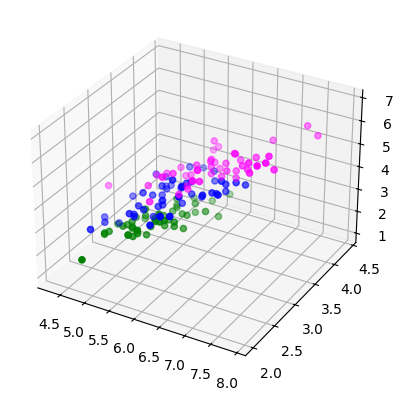

In [27]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,0],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,0],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,0],X[y==2,1],X[y==2,2],color='magenta')
plt.show()


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


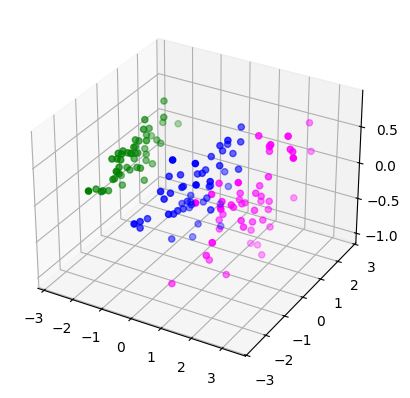

1.0000000000000009


In [28]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing, decomposition
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
n_components = 3
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show()
print(np.var(Xpp[:,1]))

[2.93808505 0.9201649  0.14774182]
[0.72962445 0.22850762 0.03668922]


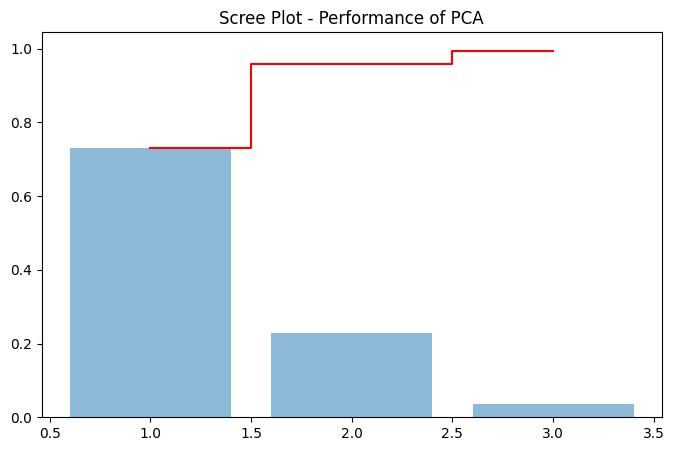

In [29]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
print(pca.explained_variance_)
print(pca.explained_variance_ratio_)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8, 5))

plt.bar(range(1, len(explained_variance) + 1), explained_variance,
        alpha=0.5, align='center')

plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance,
         where='mid', color='red')

plt.title('Scree Plot - Performance of PCA')
plt.show()

In [30]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

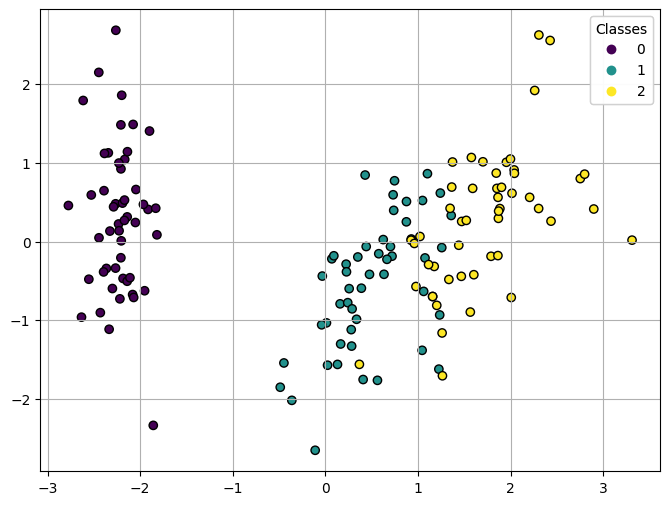

In [31]:
# Plot the principal components in 2D, mark different targets in color

plt.figure(figsize=(8, 6))
scatter = plt.scatter(Xpca[:, 0], Xpca[:, 1], c=y, cmap='viridis', edgecolors='k')

legend1 = plt.legend(*scatter.legend_elements(), title="Classes")
plt.gca().add_artist(legend1)

plt.grid(True)
plt.show()


# KNN classifier

Original 4D Dataset
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


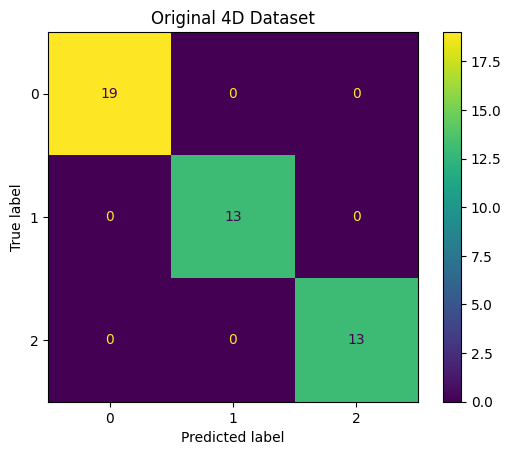

Xpp (3 features) - OK
[[19  0  0]
 [ 0 10  3]
 [ 0  2 11]]


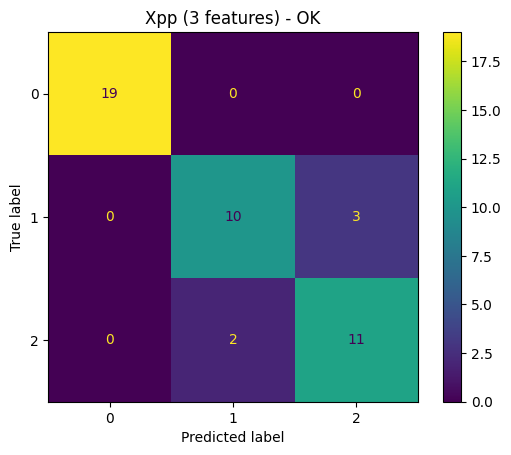

Xpp (2 features) - KO
[[19  0  0]
 [ 0  6  7]
 [ 0  2 11]]


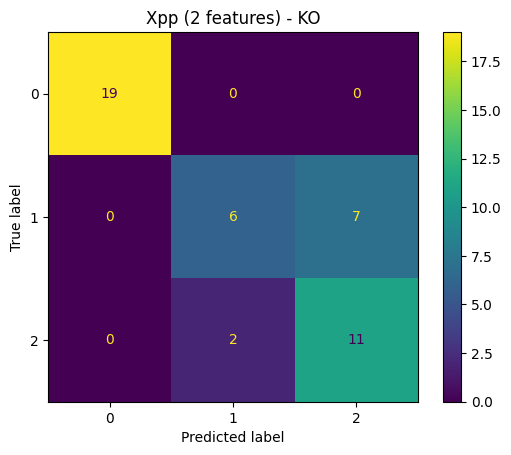

Xpca (2 components) - KO
[[19  0  0]
 [ 0 11  2]
 [ 0  0 13]]


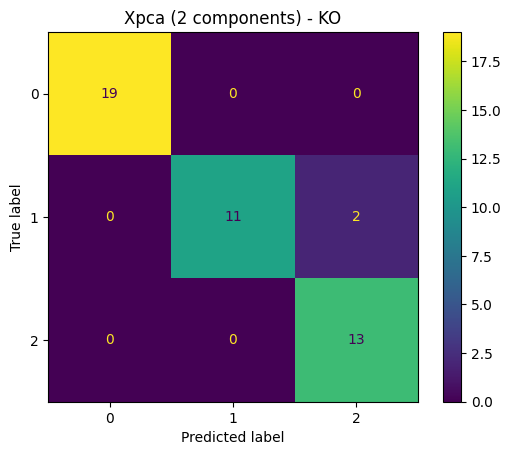

Xpca (3 components) - OK
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


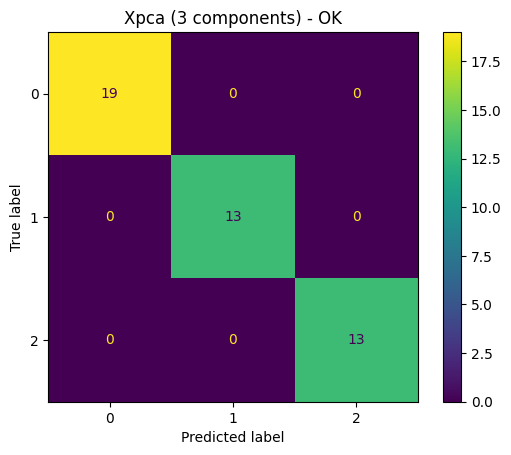

In [32]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X


# Xpp, 3 features OK
# Xpp, 2 features KO
# Xpca, 2 features KO
# Xpca, 3 features OK
# Tout les cas a traiter

from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def evaluate_scenario(X_data, y_data, title):
    X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

    knn = KNeighborsClassifier(n_neighbors=3)
    knn.fit(X_train, y_train)
    Ypred = knn.predict(X_test)

    print(title)
    print(confusion_matrix(y_test, Ypred))
    ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
    plt.title(title)
    plt.show()

scenarios = [
    (X, "Original 4D Dataset"),
    (Xpp[:, :3], "Xpp (3 features) - OK"),
    (Xpp[:, :2], "Xpp (2 features) - KO"),
    (Xpca[:, :2], "Xpca (2 components) - KO"),
    (Xpca[:, :3], "Xpca (3 components) - OK")
]

for data, name in scenarios:
    evaluate_scenario(data, y, name)



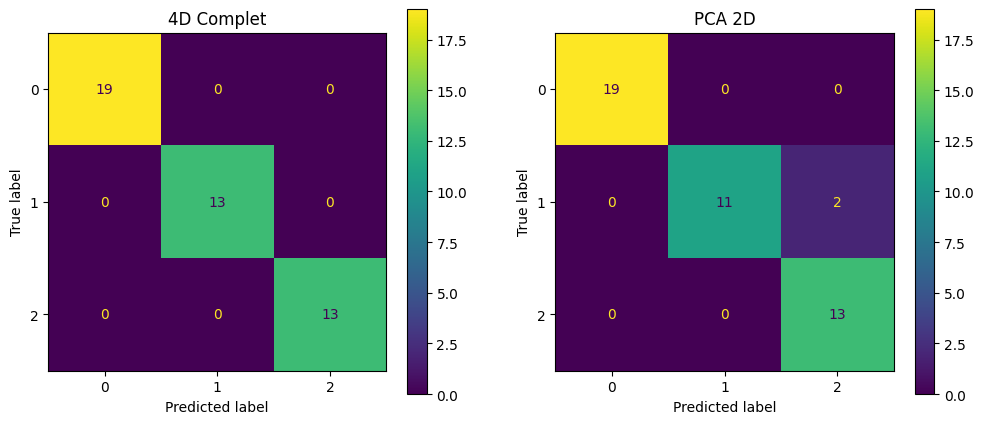

In [33]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(Xpp, y, test_size=0.3, random_state=42)
knn_full = KNeighborsClassifier(n_neighbors=3).fit(X_train_full, y_train_full)
Ypred_full = knn_full.predict(X_test_full)

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(Xpca[:, 0:2], y, test_size=0.3, random_state=42)
knn_pca = KNeighborsClassifier(n_neighbors=3).fit(X_train_pca, y_train_pca)
Ypred_pca = knn_pca.predict(X_test_pca)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(y_test_full, Ypred_full, ax=axes[0])
axes[0].set_title("4D Complet")

ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca, ax=axes[1])
axes[1].set_title("PCA 2D")

plt.show()


2D - Original Features:
[[19  0  0]
 [ 0  7  6]
 [ 0  5  8]]


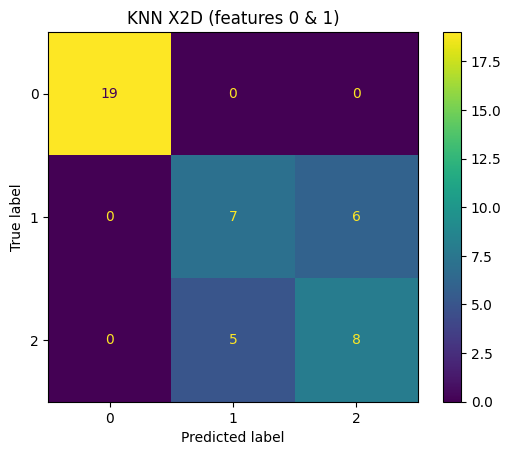

In [34]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)

X2D = X[:, :2]

X_train_2D, X_test_2D, y_train_2D, y_test_2D = train_test_split(X2D, y, test_size=0.3, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train_2D, y_train_2D)
Ypred_2D = knn2.predict(X_test_2D)

print("2D - Original Features:")
print(confusion_matrix(y_test_2D, Ypred_2D))
ConfusionMatrixDisplay.from_predictions(y_test_2D, Ypred_2D)
plt.title("KNN X2D (features 0 & 1)")
plt.show()
